In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
data = {
    'car': ['benz', 'bmw', 'lamburgini', 'pezho'],
    'model': [1945, 1945, 1999, 1999 ],
    'power': [100, 122, 350, 150]
}

df = pd.DataFrame(data)

df.groupby('car').groups
df.groupby(['car', 'model']).groups

{('benz', 1945): [0], ('bmw', 1945): [1], ('lamburgini', 1999): [2], ('pezho', 1999): [3]}

In [3]:
grouped = df.groupby('model')
for name, group in grouped:
    print(name)
    print(group)

1945
    car  model  power
0  benz   1945    100
1   bmw   1945    122
1999
          car  model  power
2  lamburgini   1999    350
3       pezho   1999    150


In [4]:
grouped.get_group(1999)
grouped.get_group(1999)['car']

2    lamburgini
3         pezho
Name: car, dtype: object

In [5]:
grouped['power'].agg(np.mean)

C:\Users\lenovo\AppData\Local\Temp\ipykernel_12144\2688913461.py:1: FutureWarning: The provided callable <function mean at 0x0000014321C63EC0> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  grouped['power'].agg(np.mean)


model
1945    111.0
1999    250.0
Name: power, dtype: float64

In [6]:
grouped['power'].agg([np.size, np.mean, np.sum, np.std])

C:\Users\lenovo\AppData\Local\Temp\ipykernel_12144\2533073723.py:1: FutureWarning: The provided callable <function mean at 0x0000014321C63EC0> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  grouped['power'].agg([np.size, np.mean, np.sum, np.std])
C:\Users\lenovo\AppData\Local\Temp\ipykernel_12144\2533073723.py:1: FutureWarning: The provided callable <function sum at 0x0000014321C62AC0> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  grouped['power'].agg([np.size, np.mean, np.sum, np.std])
C:\Users\lenovo\AppData\Local\Temp\ipykernel_12144\2533073723.py:1: FutureWarning: The provided callable <function std at 0x0000014321C84040> is currently using SeriesGroupBy.std. In a future version of pandas, the provided callable will be used directly.

,size,mean,sum,std
model,,,,
1945,2,111.0,222,15.556349
1999,2,250.0,500,141.421356


In [7]:
power = lambda x : x*1
power_ = lambda x : x*2

#print(grouped.transform(power_))
print(grouped.transform(power))

          car  power
0        benz    100
1         bmw    122
2  lamburgini    350
3       pezho    150


In [8]:
print(grouped.filter(lambda x : len(x) >= 2 ))

          car  model  power
0        benz   1945    100
1         bmw   1945    122
2  lamburgini   1999    350
3       pezho   1999    150


   date type  sales
0  2020    a  10000
1  2001    b  13000
2  2001    a  13000
3  2011    b  13000
4  2015    a  45000
5  2015    b   7000
6  2017    c  30000
7  2019    a  25000
8  2019    b  45000
9  1999    c  10000


ValueError: number of labels (2) does not match number of bars (7).

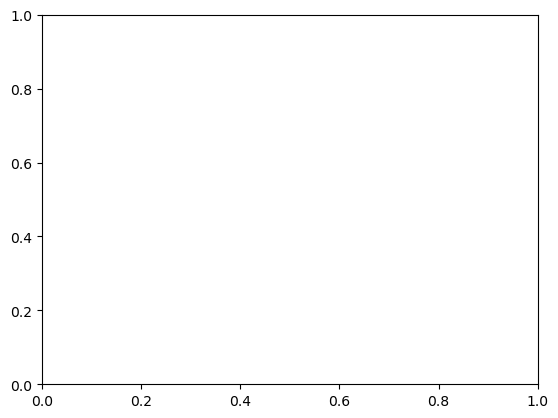

In [13]:
data = {
    'date': [2020, 2001, 2001, 2011, 2015, 2015, 2017, 2019, 2019, 1999],
    'type': ['a', 'b', 'a', 'b', 'a', 'b', 'c', 'a', 'b', 'c'],
    'sales': [10000, 13000, 13000, 13000, 45000, 7000, 30000, 25000, 45000, 10000]
}

df = pd.DataFrame(data, columns = ["date", "type", "sales"])
print(df)
# df.groupby(['date', 'type']).sum().plot(kind = 'bar')

# df.groupby(['date', 'type']).sum().unstack().plot(kind = 'bar', y = 'sales') #stacked = True

a = df.groupby(['date', 'type']).sum().unstack().fillna(0)

fig, ax = plt.subplots()
colors = ['#FF69B4', '#008080', '#A52A2A']
bottom = np.zeros(len(a))

for i, col in enumerate(a.columns):
    ax.bar(a.index, a[col], bottom = bottom, label = col, color = colors[i])
    bottom += np.array(a[col])

for bar in ax.patches:
    ax.text(
        bar.get_x() + bar.get_width() / 2, 
        bar.get_height() + bar.get_y(),
        round(bar.get_height()),
        ha = 'center',
        color = 'black',
        weight = 'bold',
        size = 10 
    )
ax.set_title('my stacked bar chart')
ax.legend()